# AEP Time Series

In [34]:
%pip install prophet


   ---------------------------------------- 0.0/13.3 MB ? eta -:--:--
   -- ------------------------------------- 0.8/13.3 MB 4.8 MB/s eta 0:00:03
   ----- ---------------------------------- 1.8/13.3 MB 4.8 MB/s eta 0:00:03
   -------- ------------------------------- 2.9/13.3 MB 4.7 MB/s eta 0:00:03
   ----------- ---------------------------- 3.9/13.3 MB 5.0 MB/s eta 0:00:02
   -------------- ------------------------- 5.0/13.3 MB 5.2 MB/s eta 0:00:02
   ------------------ --------------------- 6.3/13.3 MB 5.2 MB/s eta 0:00:02
   ---------------------- ----------------- 7.3/13.3 MB 5.2 MB/s eta 0:00:02
   ------------------------- -------------- 8.4/13.3 MB 5.2 MB/s eta 0:00:01
   ---------------------------- ----------- 9.4/13.3 MB 5.2 MB/s eta 0:00:01
   -------------------------------- ------- 10.7/13.3 MB 5.2 MB/s eta 0:00:01
   ----------------------------------- ---- 11.8/13.3 MB 5.3 MB/s eta 0:00:01
   ---------------------------------------  13.1/13.3 MB 5.3 MB/s eta 0:00:01
   

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.stattools import adfuller
from sklearn.metrics import mean_squared_error
import numpy as np

# load sample data
data = pd.read_csv("AEP_hourly.csv")

# ubah ke datetime
data['Datetime'] = pd.to_datetime(data['Datetime'])

# set sebagai index
data.set_index('Datetime', inplace=True)

# tampilkan 5 data teratas
print(data.head())


In [7]:
import pandas as pd 
data = pd.read_csv("../data/datasets/AEP_hourly.csv")

data.head()


,Datetime,AEP_MW
0,2004-12-31 01:00:00,13478.0
1,2004-12-31 02:00:00,12865.0
2,2004-12-31 03:00:00,12577.0
3,2004-12-31 04:00:00,12517.0
4,2004-12-31 05:00:00,12670.0


In [8]:
# ubah ke datetime
data['Datetime'] = pd.to_datetime(data['Datetime'])

In [9]:
# set sebagai index
data.set_index('Datetime', inplace=True)

In [10]:
# tampilkan 5 data teratas
print(data.head())

                      AEP_MW
Datetime                    
2004-12-31 01:00:00  13478.0
2004-12-31 02:00:00  12865.0
2004-12-31 03:00:00  12577.0
2004-12-31 04:00:00  12517.0
2004-12-31 05:00:00  12670.0


In [25]:
# Total per hari
daily_data = data.resample('D').sum()

print(daily_data.head())


              AEP_MW
Datetime            
2004-10-01  328544.0
2004-10-02  311997.0
2004-10-03  293450.0
2004-10-04  343417.0
2004-10-05  346553.0


In [36]:
daily_data.tail()

,AEP_MW
Datetime,
2018-07-30,368834.0
2018-07-31,364327.0
2018-08-01,363628.0
2018-08-02,376504.0
2018-08-03,14809.0


In [37]:
daily_data.shape

(5055, 1)

In [38]:
daily_data.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 5055 entries, 2004-10-01 to 2018-08-03
Freq: D
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AEP_MW  5055 non-null   float64
dtypes: float64(1)
memory usage: 79.0 KB


# Plot Time Series

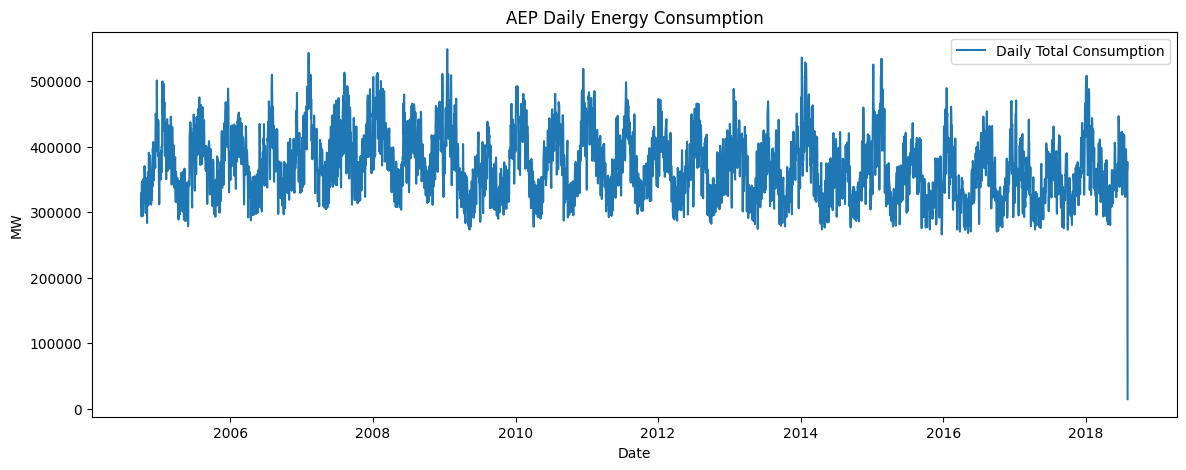

In [26]:
plt.figure(figsize=(14,5))
plt.plot(daily_data, label="Daily Total Consumption")
plt.title("AEP Daily Energy Consumption")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.show()


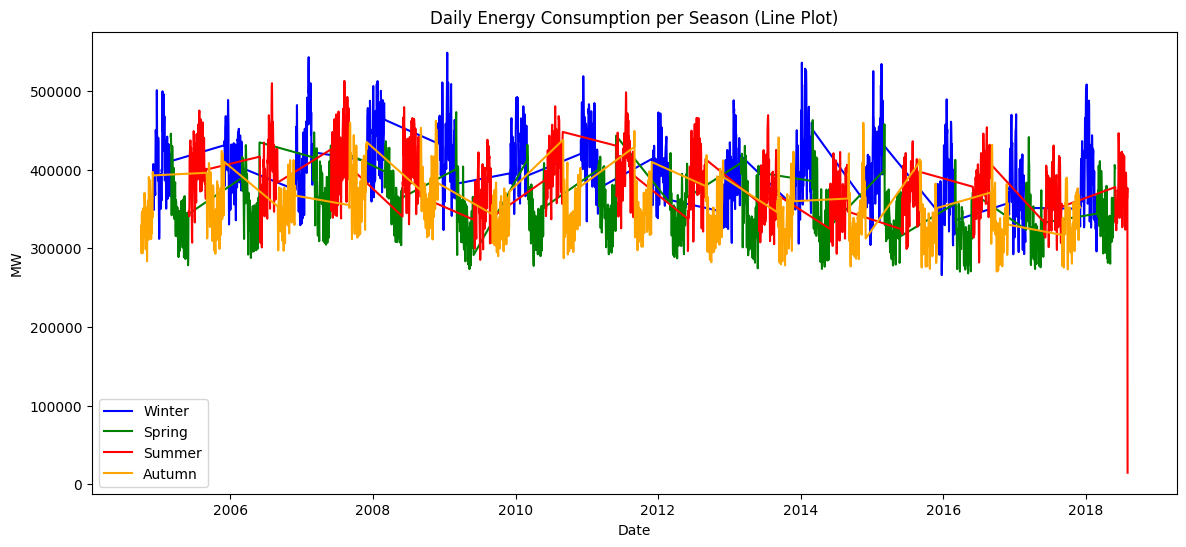

In [90]:
plt.figure(figsize=(14,6))

# Loop tiap musim dan plot
seasons = ['Winter', 'Spring', 'Summer', 'Autumn']
colors = {'Winter':'blue', 'Spring':'green', 'Summer':'red', 'Autumn':'orange'}

for season in seasons:
    season_data = df[df['Season'] == season]
    plt.plot(season_data['Datetime'], season_data['AEP_MW'], color=colors[season], label=season)

plt.title("Daily Energy Consumption per Season (Line Plot)")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.show()


# Stasionarity

# Rolling Mean & Std of AEP

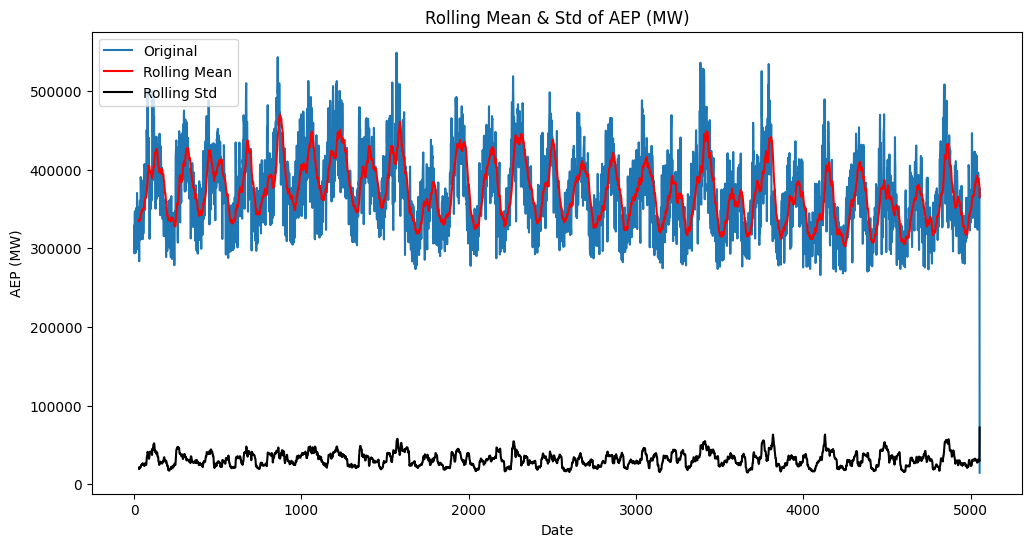

In [76]:
import matplotlib.pyplot as plt

window = 30  # misal rolling 30 hari
rolling_mean = df['y'].rolling(window=window).mean()
rolling_std = df['y'].rolling(window=window).std()

plt.figure(figsize=(12,6))
plt.plot(df['y'], label='Original')
plt.plot(rolling_mean, color='red', label='Rolling Mean')
plt.plot(rolling_std, color='black', label='Rolling Std')
plt.xlabel('Date')
plt.ylabel('AEP (MW)')
plt.legend()
plt.title('Rolling Mean & Std of AEP (MW)')
plt.show()


In [77]:
from statsmodels.tsa.stattools import adfuller

adf_result = adfuller(df['y'])
print('--- Augmented Dickey-Fuller Test ---')
print('ADF Statistic:', adf_result[0])
print('p-value:', adf_result[1])
print('Critical Values:')
for key, value in adf_result[4].items():
    print(f'   {key}: {value}')


# Kesimpulan Stasioneritas
if adf_result[1] < 0.05:
    print("\nKesimpulan: Data stasioner (tolak H0)")
else:
    print("\nKesimpulan: Data non-stasioner (gagal tolak H0)")

--- Augmented Dickey-Fuller Test ---
ADF Statistic: -7.279596355145723
p-value: 1.5125837189548947e-10
Critical Values:
   1%: -3.4316522779278373
   5%: -2.8621154666284063
   10%: -2.5670763214801435

Kesimpulan: Data stasioner (tolak H0)


# Decomposition

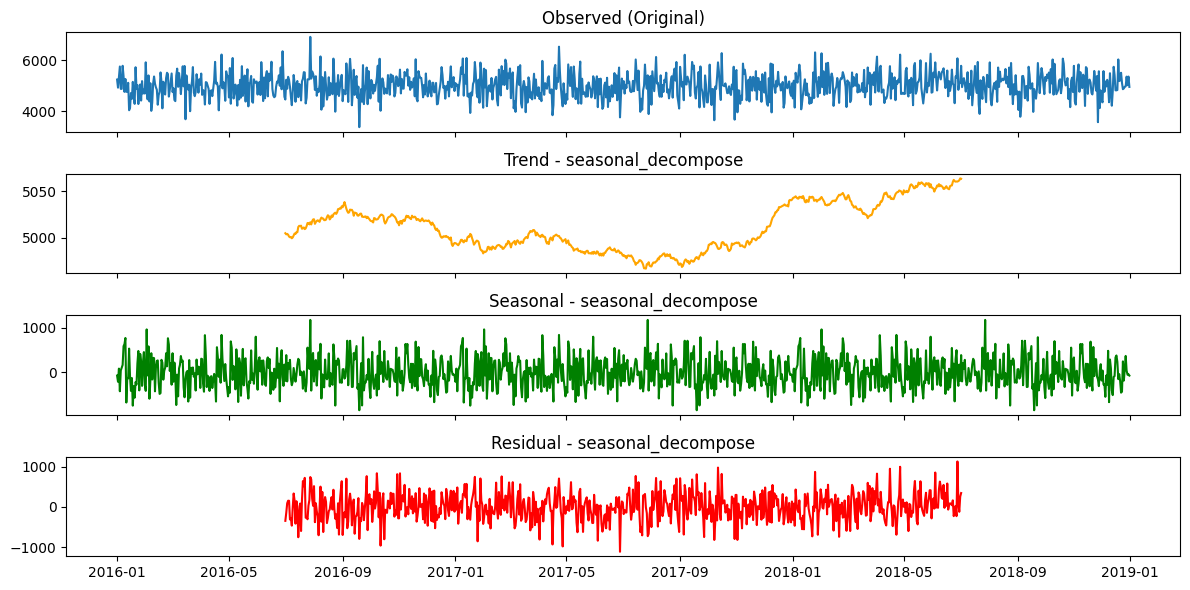

In [142]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --- 1. Decompose time series (misal pola tahunan, 365 hari) ---
decomp = seasonal_decompose(daily_data['AEP_MW'], model='additive', period=365)

# --- 2. Plot hasil dekomposisi ---
fig, axes = plt.subplots(4, 1, figsize=(12, 6), sharex=True)

# Observed
axes[0].plot(daily_data.index, daily_data['AEP_MW'])
axes[0].set_title("Observed (Original)")

# Trend
axes[1].plot(decomp.trend, color='orange')
axes[1].set_title("Trend - seasonal_decompose")

# Seasonal
axes[2].plot(decomp.seasonal, color='green')
axes[2].set_title("Seasonal - seasonal_decompose")

# Residual
axes[3].plot(decomp.resid, color='red')
axes[3].set_title("Residual - seasonal_decompose")

plt.tight_layout()
plt.show()


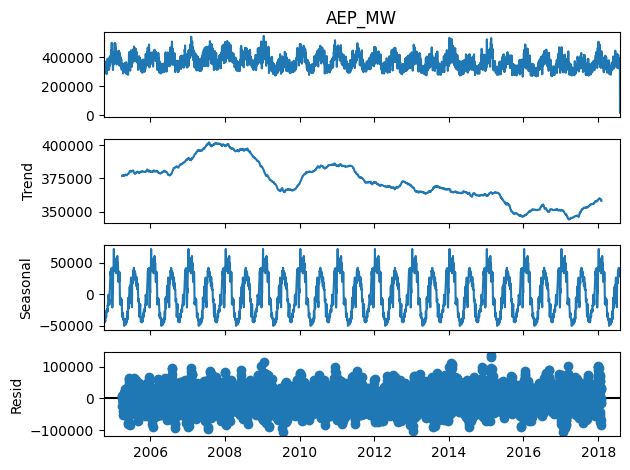

In [47]:
# Decompose data (asumsi period = 30 untuk pola bulanan)
decomposition = seasonal_decompose(daily_data['AEP_MW'], model='additive', period=365)

# Plot hasil
decomposition.plot()
plt.show()


# Decomposition STL

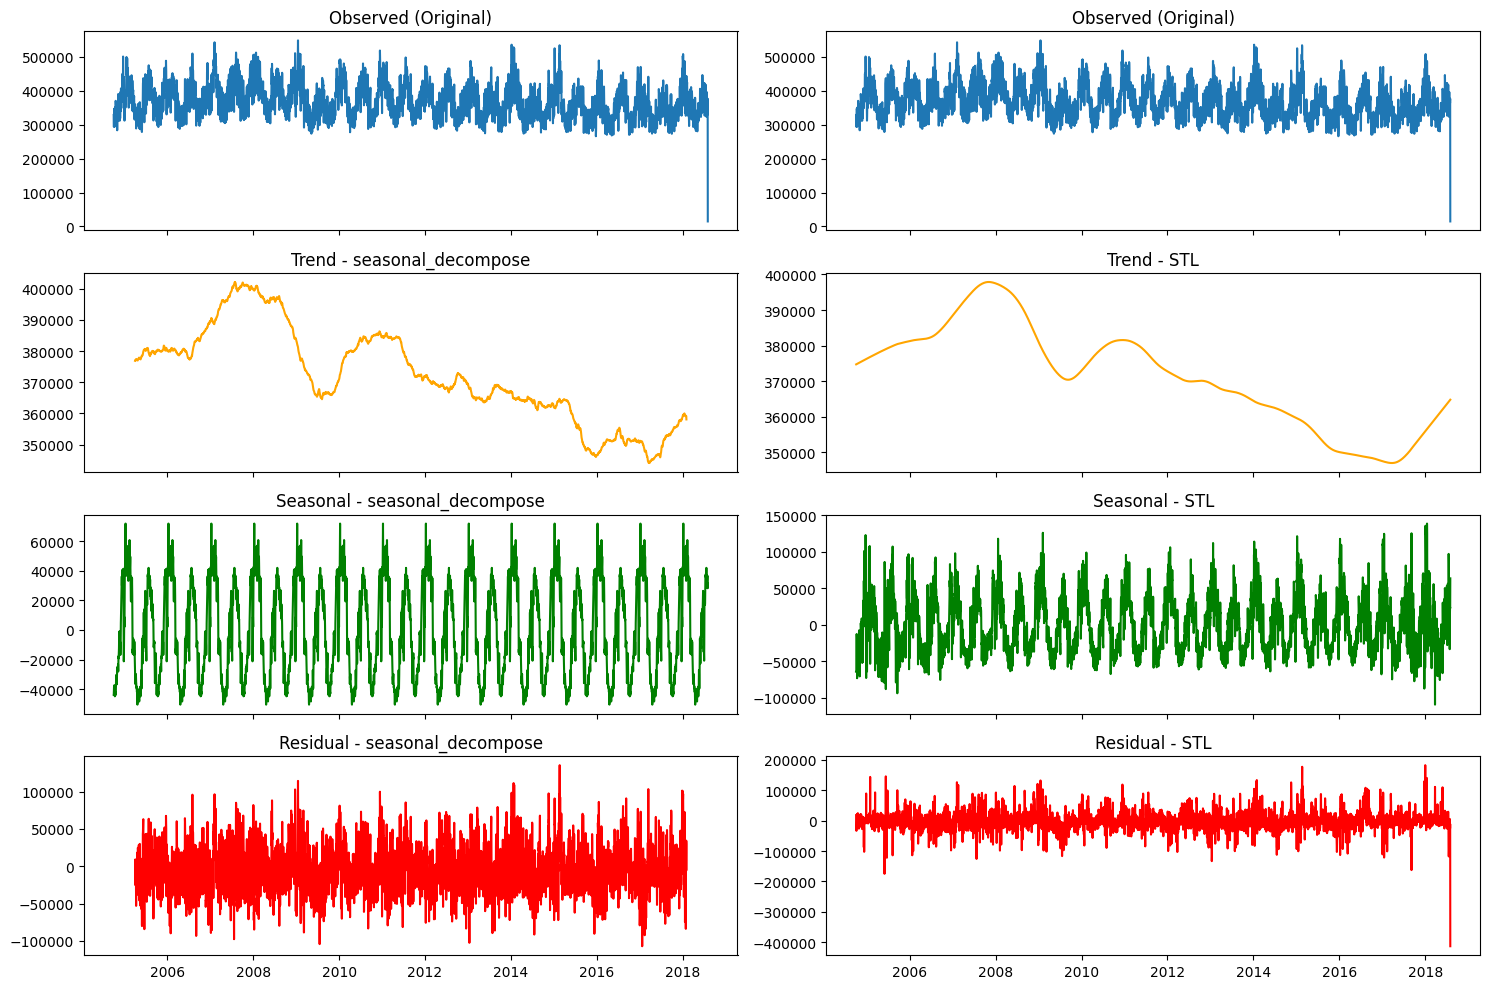

In [46]:
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose, STL


# --- 2. seasonal_decompose (misal pola bulanan, 30 hari) ---
decomp = seasonal_decompose(daily_data['AEP_MW'], model='additive', period=365)

# --- 3. STL decomposition (pola tahunan, 365 hari) ---
stl = STL(daily_data['AEP_MW'], period=365, robust=True)
res = stl.fit()

# --- 4. Plot perbandingan ---
fig, axes = plt.subplots(4, 2, figsize=(15, 10), sharex=True)

# Observed
axes[0,0].plot(daily_data.index, daily_data['AEP_MW']); axes[0,0].set_title("Observed (Original)")
axes[0,1].plot(daily_data.index, daily_data['AEP_MW']); axes[0,1].set_title("Observed (Original)")

# Trend
axes[1,0].plot(decomp.trend, color='orange'); axes[1,0].set_title("Trend - seasonal_decompose")
axes[1,1].plot(res.trend, color='orange'); axes[1,1].set_title("Trend - STL")

# Seasonal
axes[2,0].plot(decomp.seasonal, color='green'); axes[2,0].set_title("Seasonal - seasonal_decompose")
axes[2,1].plot(res.seasonal, color='green'); axes[2,1].set_title("Seasonal - STL")

# Residual
axes[3,0].plot(decomp.resid, color='red'); axes[3,0].set_title("Residual - seasonal_decompose")
axes[3,1].plot(res.resid, color='red'); axes[3,1].set_title("Residual - STL")

plt.tight_layout()
plt.show()


# Holt-Winters

d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


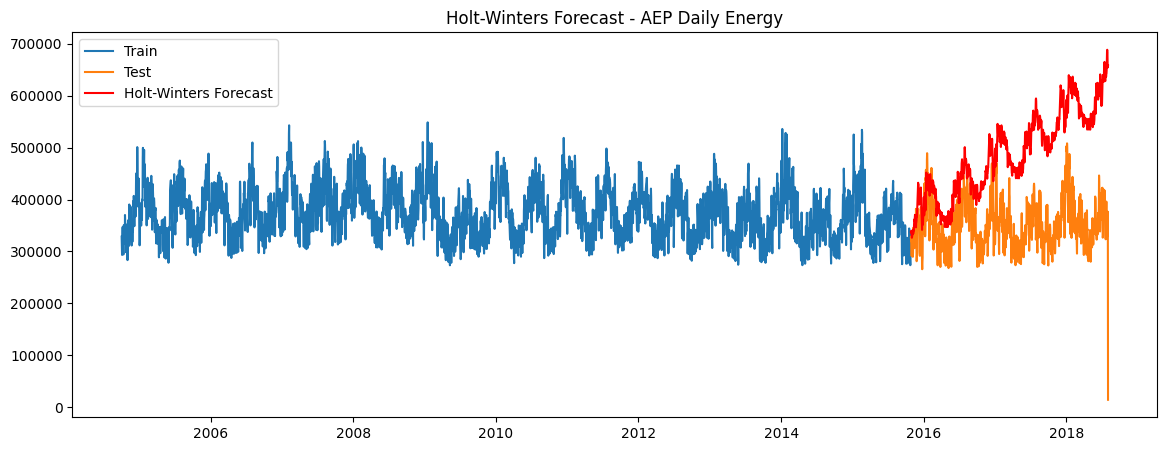

RMSE Holt-Winters: 157548.40554556422


In [51]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import numpy as np

# Split train-test (80%-20%)
train_size = int(len(daily_data) * 0.8)
train, test = daily_data.iloc[:train_size], daily_data.iloc[train_size:]

# Holt-Winters dengan trend + seasonality
model = ExponentialSmoothing(train['AEP_MW'],
                             trend="add",
                             seasonal="add",
                             seasonal_periods=365).fit()

forecast = model.forecast(len(test))

# Plot
plt.figure(figsize=(14,5))
plt.plot(train['AEP_MW'], label="Train")
plt.plot(test['AEP_MW'], label="Test")
plt.plot(forecast, label="Holt-Winters Forecast", color="red")
plt.legend()
plt.title("Holt-Winters Forecast - AEP Daily Energy")
plt.show()

# Evaluasi
rmse = np.sqrt(mean_squared_error(test['AEP_MW'], forecast))
print("RMSE Holt-Winters:", rmse)


In [80]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# Split data (80% train, 20% test)
train_size = int(len(daily_data) * 0.8)
train, test = daily_data.iloc[:train_size], daily_data.iloc[train_size:]

# Fit Holt-Winters
hw_model = ExponentialSmoothing(train['AEP_MW'],
                                trend="add",
                                seasonal="add",
                                seasonal_periods=365).fit()

hw_forecast = hw_model.forecast(len(test))

# RMSE Holt-Winters
rmse_hw = np.sqrt(mean_squared_error(test['AEP_MW'], hw_forecast))
print("RMSE Holt-Winters:", rmse_hw)


RMSE Holt-Winters: 157548.40554556422


d:\Technical Class\Python\myvenv\Lib\site-packages\statsmodels\tsa\holtwinters\model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


In [81]:
# RMSE dalam persen
rmse_hw_percent = (rmse_hw / test['AEP_MW'].mean()) * 100
print("RMSE Holt-Winters (%):", rmse_hw_percent)


RMSE Holt-Winters (%): 44.650626301954425


# Prophet

In [196]:
# --- 1. Format data untuk Prophet (rename dengan benar) ---
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"}).copy()

# Kalau ternyata kolom namanya 'index', ganti juga:
df = df.rename(columns={"index": "ds"})

# Pastikan hasil rename benar
print(df.head())
print(df.columns)


          ds            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter
Index(['ds', 'y', 'Season'], dtype='object')


11:32:37 - cmdstanpy - INFO - Chain [1] start processing
11:32:38 - cmdstanpy - INFO - Chain [1] done processing


RMSE Prophet: 491.84488125251625


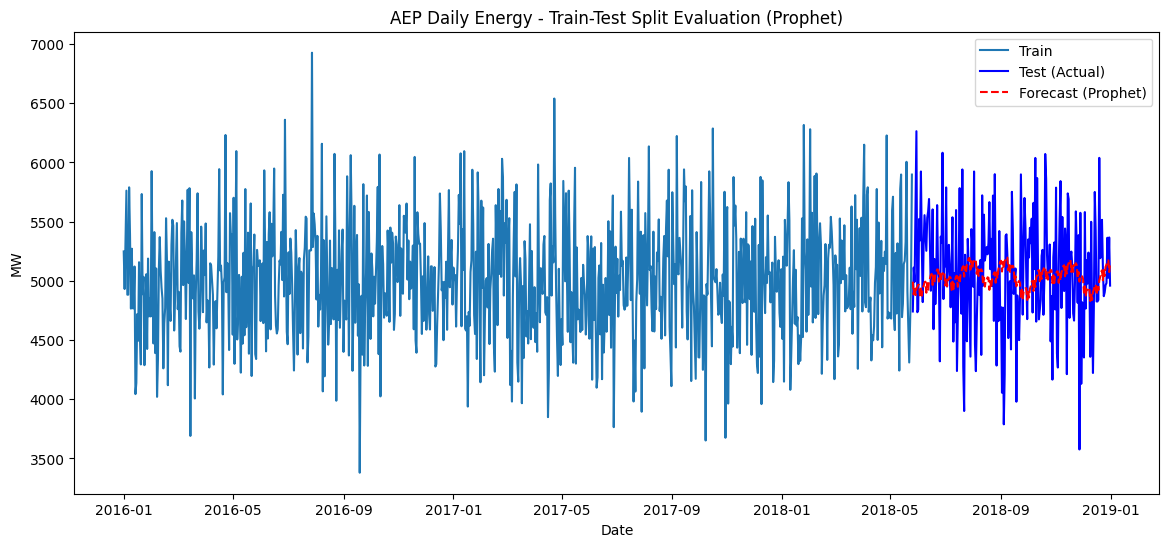

In [176]:
# --- 2. Train-test split ---
train_size = int(len(df) * 0.8)
train = df.iloc[:train_size].copy()
test = df.iloc[train_size:].copy()

# --- 3. Fit Prophet ---
prophet_model = Prophet(daily_seasonality=False, yearly_seasonality=True, weekly_seasonality=True)
prophet_model.fit(train[['ds', 'y']])

# --- 4. Buat future dataframe hanya sampai akhir test ---
future = pd.concat([train[['ds']], test[['ds']]])  # gabungkan tanggal train+test
prophet_forecast = prophet_model.predict(future)

# --- 5. Ambil hasil prediksi untuk periode test ---
yhat = prophet_forecast.set_index('ds').loc[test['ds'], ['yhat']]

# --- 6. Evaluasi RMSE ---
rmse_prophet = np.sqrt(mean_squared_error(test['y'], yhat['yhat']))
print("RMSE Prophet:", rmse_prophet)

# --- 7. Plot Train vs Test vs Forecast ---
plt.figure(figsize=(14,6))
plt.plot(train['ds'], train['y'], label="Train")
plt.plot(test['ds'], test['y'], label="Test (Actual)", color="blue")
plt.plot(yhat.index, yhat['yhat'], label="Forecast (Prophet)", color="red", linestyle="--")
plt.title("AEP Daily Energy - Train-Test Split Evaluation (Prophet)")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.show()


In [207]:
# RMSE dalam persen untuk Prophet
rmse_prophet_percent = (rmse_prophet / test['y'].mean()) * 100
print("RMSE Prophet (%):", rmse_prophet_percent)


RMSE Prophet (%): 9.690201788190361


# Holt-Winters vs Prophet

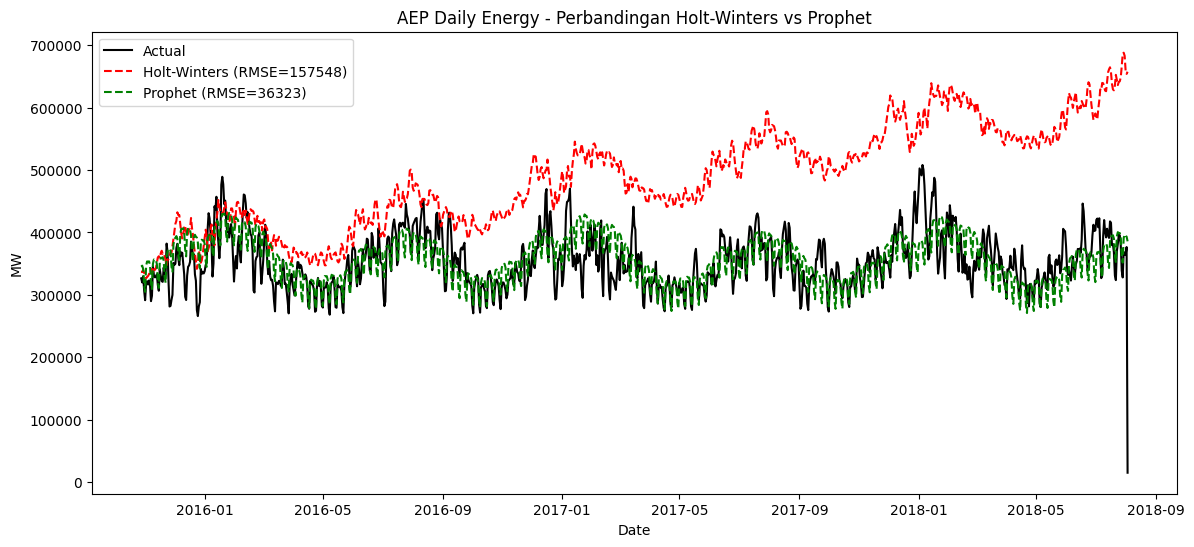

In [59]:
plt.figure(figsize=(14,6))
plt.plot(test.index, test['AEP_MW'], label="Actual", color="black")
plt.plot(test.index, hw_forecast, label=f"Holt-Winters (RMSE={rmse_hw:.0f})", color="red", linestyle="--")
plt.plot(test.index, yhat.values, label=f"Prophet (RMSE={rmse_prophet:.0f})", color="green", linestyle="--")

plt.title("AEP Daily Energy - Perbandingan Holt-Winters vs Prophet")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.show()


# Using Prophet

In [238]:
# --- 1. Format data untuk Prophet (rename dengan benar) ---
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"}).copy()

# Kalau ternyata kolom namanya 'index', ganti juga:
df = df.rename(columns={"index": "ds"})

# Pastikan hasil rename benar
print(df.head())
print(df.columns)


          ds            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter
Index(['ds', 'y', 'Season'], dtype='object')


In [193]:
# Gunakan tanggal train + test, bukan masa depan
future = pd.concat([train[['ds']], test[['ds']]])  
prophet_forecast = prophet_model.predict(future)

# Ambil hasil prediksi hanya di periode test
yhat = prophet_forecast.set_index('ds').loc[test['ds'], ['yhat']]


In [229]:
# --- 1. Format data untuk Prophet (rename dengan benar) ---
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"}).copy()

# Kalau ternyata kolom namanya 'index', ganti juga:
df = df.rename(columns={"index": "ds"})

# Pastikan hasil rename benar
print(df.head())
print(df.columns)


          ds            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter
Index(['ds', 'y', 'Season'], dtype='object')


In [220]:
# --- 1. Format data untuk Prophet (rename dengan benar) ---
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"}).copy()

# Kalau ternyata kolom namanya 'index', ganti juga:
df = df.rename(columns={"index": "ds"})

# Pastikan hasil rename benar
print(df.head())
print(df.columns)

          ds            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter
Index(['ds', 'y', 'Season'], dtype='object')


In [183]:
print(df.columns)
print(train.head())
print(test.head())


Index(['ds', 'y', 'Season'], dtype='object')
       index            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter
         index            y Season
876 2018-05-26  4741.194350  Other
877 2018-05-27  5111.893976  Other
878 2018-05-28  4991.788552  Other
879 2018-05-29  5594.196637  Other
880 2018-05-30  6263.466213  Other


In [185]:
train = train.rename(columns={"index": "ds"})
test  = test.rename(columns={"index": "ds"})


In [189]:
print(daily_data.reset_index().columns)


Index(['index', 'AEP_MW', 'Season'], dtype='object')


In [190]:
df = daily_data.reset_index().rename(columns={"index": "ds", "AEP_MW": "y"})


In [171]:
print(df.columns)
print(train.head())


Index(['index', 'y', 'Season'], dtype='object')
       index            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter


In [83]:
from prophet import Prophet

# Format data untuk Prophet
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"})
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Fit Prophet
prophet_model = Prophet(daily_seasonality=False, yearly_seasonality=True)
prophet_model.fit(train)

# Forecast sepanjang test set
future = prophet_model.make_future_dataframe(periods=len(test))
prophet_forecast = prophet_model.predict(future)

# Ambil hasil prediksi untuk test period
yhat = prophet_forecast['yhat'].iloc[-len(test):]

# RMSE Prophet
rmse_prophet = np.sqrt(mean_squared_error(test['y'], yhat))
print("RMSE Prophet:", rmse_prophet)


09:02:41 - cmdstanpy - INFO - Chain [1] start processing
09:02:42 - cmdstanpy - INFO - Chain [1] done processing


RMSE Prophet: 36322.894129473345


In [84]:
# RMSE dalam persen untuk Prophet
rmse_prophet_percent = (rmse_prophet / test['y'].mean()) * 100
print("RMSE Prophet (%):", rmse_prophet_percent)


RMSE Prophet (%): 10.294232850941293


01:46:19 - cmdstanpy - INFO - Chain [1] start processing
01:46:20 - cmdstanpy - INFO - Chain [1] done processing


RMSE Prophet: 36322.894129473345


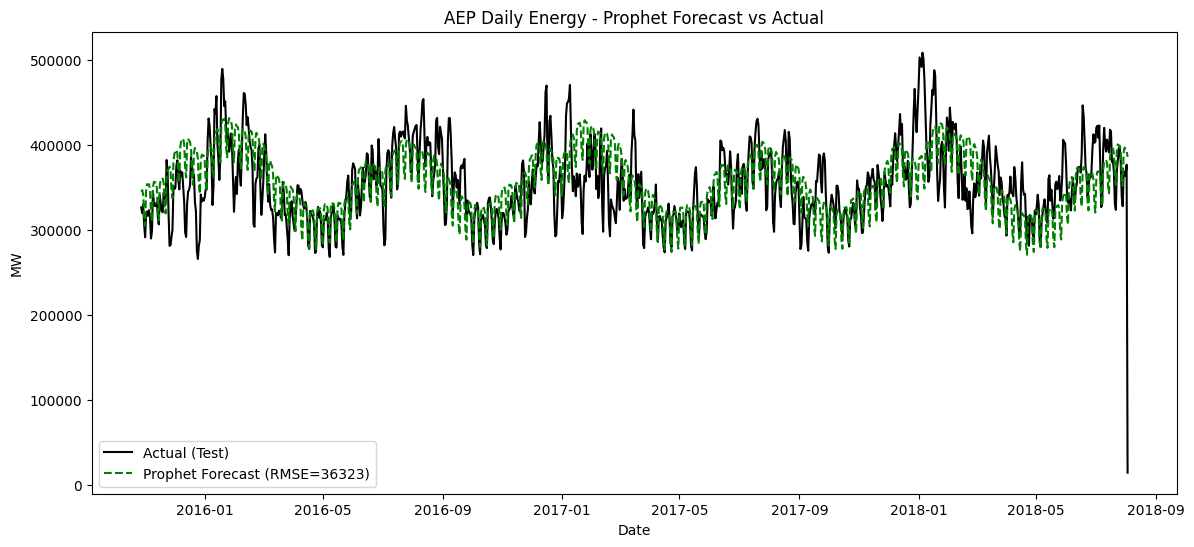

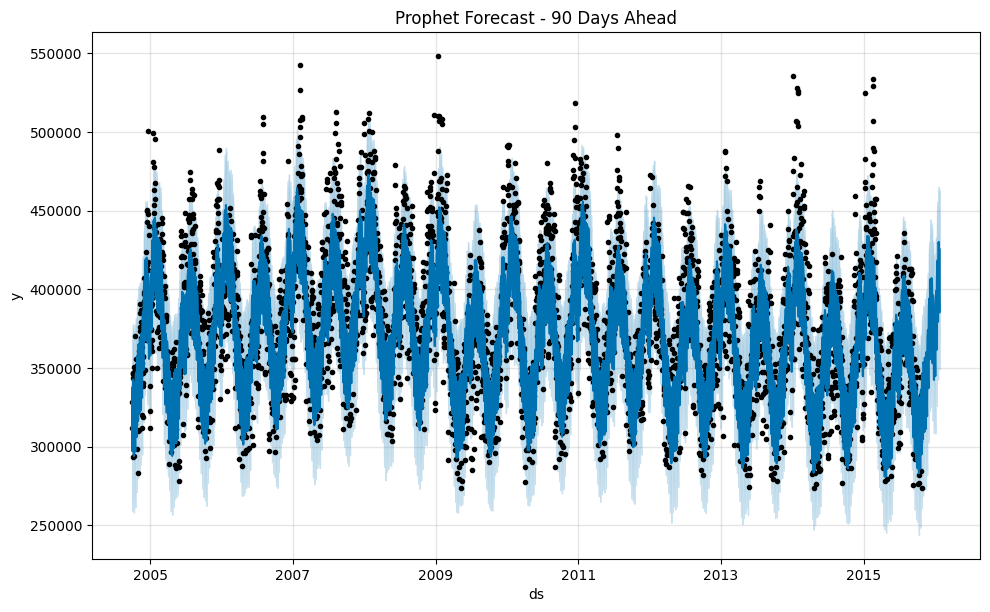

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
from prophet import Prophet
from sklearn.metrics import mean_squared_error
import numpy as np

# Format data untuk Prophet
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"})

# --- 2. Train-test split (80% - 20%) ---
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# --- 3. Fit model Prophet ---
model = Prophet(daily_seasonality=False, yearly_seasonality=True)
model.fit(train)

# --- 4. Forecast sepanjang test set ---
future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

# Ambil prediksi test period
yhat = forecast['yhat'].iloc[-len(test):]

# --- 5. Evaluasi RMSE ---
rmse = np.sqrt(mean_squared_error(test['y'], yhat))
print("RMSE Prophet:", rmse)

# --- 6. Plot hasil Test vs Forecast ---
plt.figure(figsize=(14,6))
plt.plot(test['ds'], test['y'], label="Actual (Test)", color="black")
plt.plot(test['ds'], yhat.values, label=f"Prophet Forecast (RMSE={rmse:.0f})", color="green", linestyle="--")
plt.title("AEP Daily Energy - Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("MW")
plt.legend()
plt.show()

# --- 7. Forecast ke depan (90 hari setelah data terakhir) ---
future_forecast = model.make_future_dataframe(periods=90)
forecast_future = model.predict(future_forecast)

# Plot prediksi 90 hari ke depan
model.plot(forecast_future)
plt.title("Prophet Forecast - 90 Days Ahead")
plt.show()


In [62]:
print("Tanggal terakhir dalam dataset:", df['ds'].max())


Tanggal terakhir dalam dataset: 2018-08-03 00:00:00


02:01:38 - cmdstanpy - INFO - Chain [1] start processing
02:01:39 - cmdstanpy - INFO - Chain [1] done processing


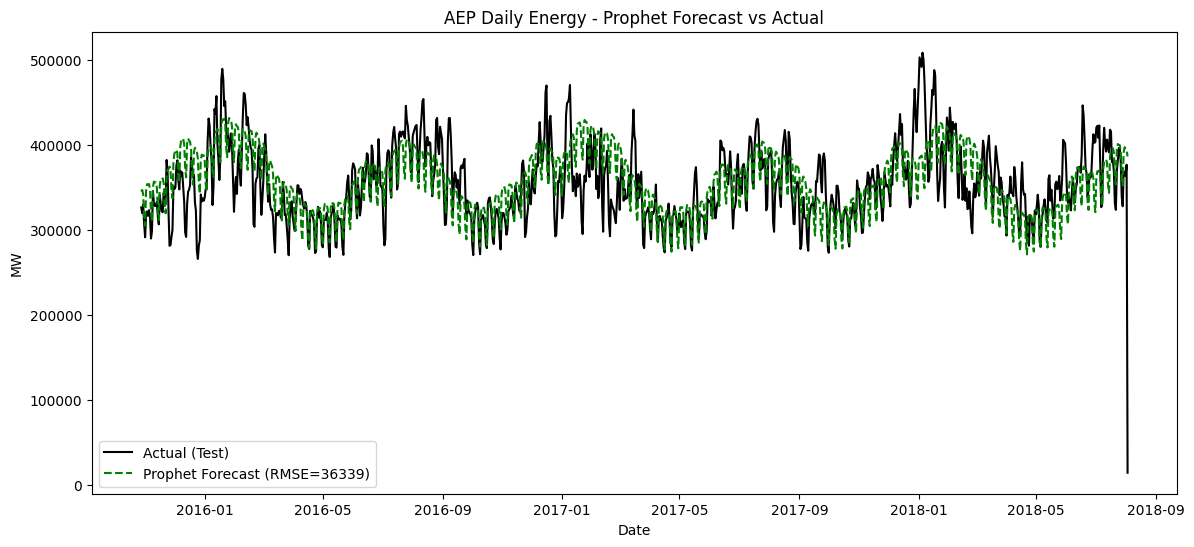

In [63]:
from prophet import Prophet
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error


# Split train-test (contoh: 80% train, 20% test)
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# --- 2. Fit Prophet ---
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(train)

# --- 3. Forecast hanya sepanjang test ---
future = model.make_future_dataframe(periods=len(test))  # jumlah test
forecast = model.predict(future)

# Ambil hanya hasil untuk test period
forecast_test = forecast.iloc[-len(test):]

# --- 4. Plot Actual vs Forecast ---
plt.figure(figsize=(14,6))
plt.plot(test['ds'], test['y'], label="Actual (Test)", color="black")
plt.plot(test['ds'], forecast_test['yhat'], label=f"Prophet Forecast (RMSE={np.sqrt(mean_squared_error(test['y'], forecast_test['yhat'])):.0f})", linestyle="--", color="green")
plt.legend()
plt.xlabel("Date")
plt.ylabel("MW")
plt.title("AEP Daily Energy - Prophet Forecast vs Actual")
plt.show()


02:02:02 - cmdstanpy - INFO - Chain [1] start processing
02:02:03 - cmdstanpy - INFO - Chain [1] done processing


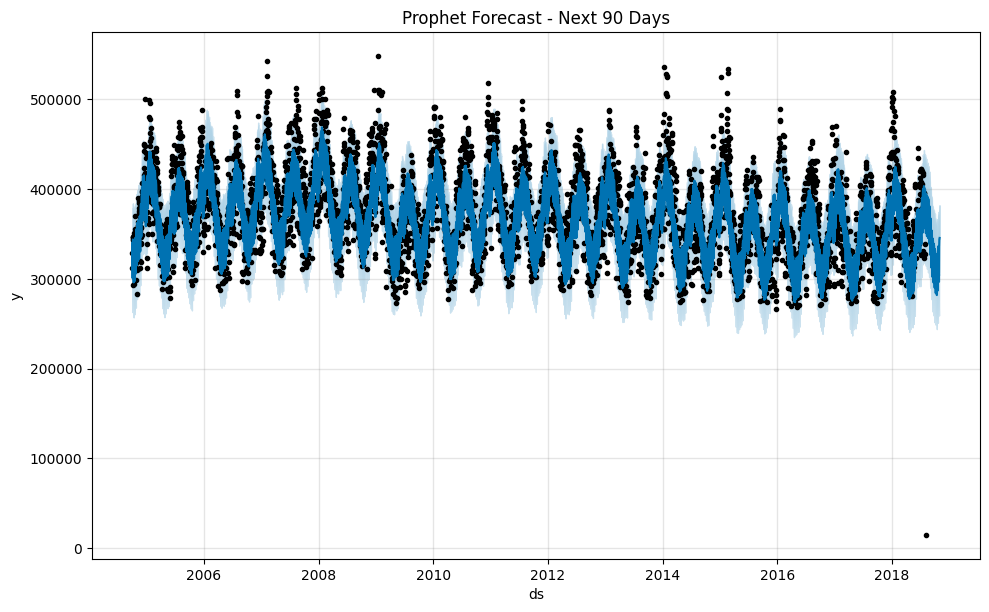

In [64]:
# Train pakai seluruh data
model = Prophet(daily_seasonality=True, yearly_seasonality=True)
model.fit(df)

# Forecast 90 hari ke depan
future = model.make_future_dataframe(periods=90)  # 3 bulan ≈ 90 hari
forecast = model.predict(future)

# Plot hasil forecast (hanya 90 hari ahead)
model.plot(forecast)
plt.title("Prophet Forecast - Next 90 Days")
plt.show()


In [230]:
# --- 1. Format data untuk Prophet (rename dengan benar) ---
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"}).copy()

# Kalau ternyata kolom namanya 'index', ganti juga:
df = df.rename(columns={"index": "ds"})

# Pastikan hasil rename benar
print(df.head())
print(df.columns)

          ds            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter
Index(['ds', 'y', 'Season'], dtype='object')


In [232]:
print(daily_data.reset_index().columns)


Index(['index', 'AEP_MW', 'Season'], dtype='object')


In [242]:
# --- 1. Format data untuk Prophet (rename dengan benar) ---
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"}).copy()

# Kalau ternyata kolom namanya 'index', ganti juga:
df = df.rename(columns={"index": "ds"})

# Pastikan hasil rename benar
print(df.head())
print(df.columns)


          ds            y  Season
0 2016-01-01  5248.357077  Winter
1 2016-01-02  4930.867849  Winter
2 2016-01-03  5323.844269  Winter
3 2016-01-04  5761.514928  Winter
4 2016-01-05  4882.923313  Winter
Index(['ds', 'y', 'Season'], dtype='object')


In [243]:
from prophet import Prophet
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import mean_squared_error

# --- 1. Siapkan data ---
df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"})

# -------------------------------
# 2. EVALUASI (Train-Test Split)
# -------------------------------
train_size = int(len(df) * 0.8)
train, test = df.iloc[:train_size], df.iloc[train_size:]

# Fit Prophet pada train
model_eval = Prophet(daily_seasonality=True, yearly_seasonality=True)
model_eval.fit(train)

# Forecast sepanjang test set
future_eval = model_eval.make_future_dataframe(periods=len(test))
forecast_eval = model_eval.predict(future_eval)

# Ambil hanya hasil untuk test
forecast_test = forecast_eval.iloc[-len(test):]

# RMSE
rmse_eval = np.sqrt(mean_squared_error(test['y'], forecast_test['yhat']))

# Plot evaluasi
plt.figure(figsize=(14,6))
plt.plot(test['ds'], test['y'], label="Actual (Test)", color="black")
plt.plot(test['ds'], forecast_test['yhat'], label=f"Prophet Forecast (RMSE={rmse_eval:.0f})", linestyle="--", color="green")
plt.legend()
plt.xlabel("Date")
plt.ylabel("MW")
plt.title("AEP Daily Energy - Prophet Forecast vs Actual")
plt.show()


# PREDIKSI 6 BULAN KE DEPAN
# --------------------------------
model_future = Prophet(daily_seasonality=True, yearly_seasonality=True)
model_future.fit(df)

# Forecast 180 hari ke depan
future_180 = model_future.make_future_dataframe(periods=180)
forecast_180 = model_future.predict(future_180)

# Plot hasil 180 hari ahead
model_future.plot(forecast_180)
plt.title("Prophet Forecast - Next 180 Days Ahead")
plt.xlabel("Date")
plt.ylabel("MW")
plt.show()


ValueError: Dataframe must have columns "ds" and "y" with the dates and values respectively.

02:11:45 - cmdstanpy - INFO - Chain [1] start processing
02:11:46 - cmdstanpy - INFO - Chain [1] done processing


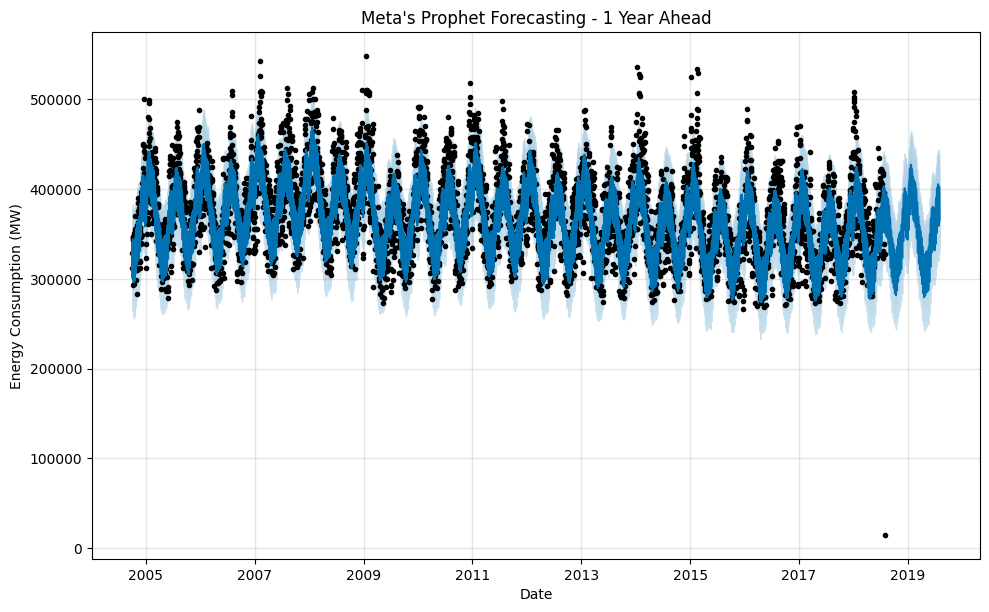

In [67]:
# Fit Prophet di seluruh data
model_future = Prophet(daily_seasonality=True, yearly_seasonality=True)
model_future.fit(df)

# Forecast 365 hari ke depan
future = model_future.make_future_dataframe(periods=365)
forecast = model_future.predict(future)

# Plot hasil dengan interval
fig = model_future.plot(forecast, xlabel="Date", ylabel="Energy Consumption (MW)")
plt.title("Meta's Prophet Forecasting - 1 Year Ahead")
plt.show()


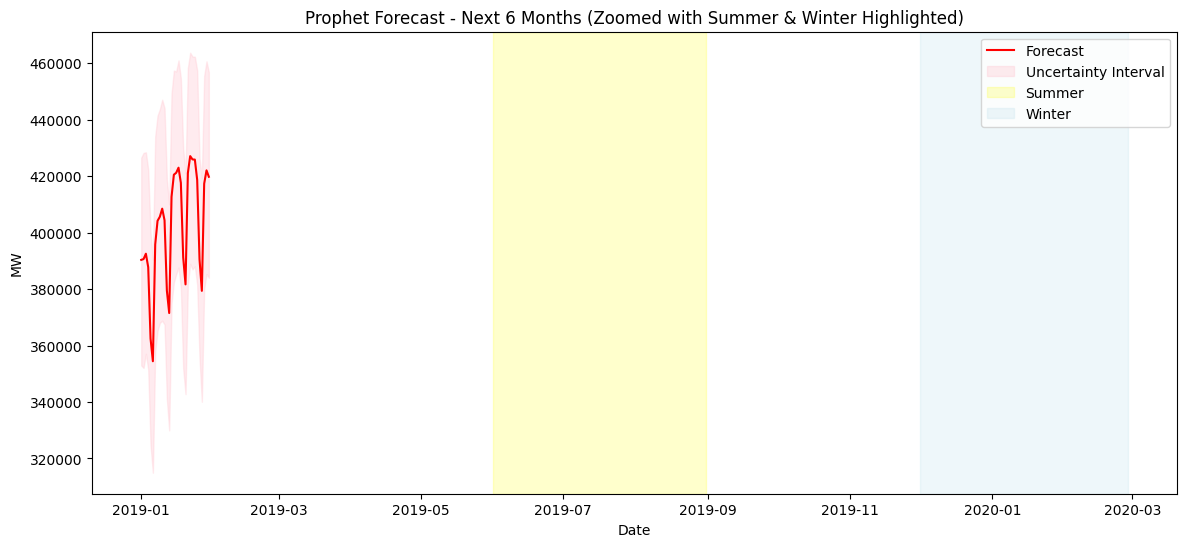

In [226]:
import matplotlib.pyplot as plt

# --- 1. Ambil tanggal terakhir dari data asli ---
last_date = df['ds'].max()
forecast_future = forecast_180[forecast_180['ds'] > last_date]

# --- 2. Plot forecast setelah data terakhir ---
plt.figure(figsize=(14,6))
plt.plot(forecast_future['ds'], forecast_future['yhat'], label="Forecast", color="red")
plt.fill_between(forecast_future['ds'], 
                 forecast_future['yhat_lower'], 
                 forecast_future['yhat_upper'], 
                 color="pink", alpha=0.3, label="Uncertainty Interval")

# --- 3. Tandai Summer (Jun–Aug) & Winter (Dec–Feb) ---
for year in forecast_future['ds'].dt.year.unique():
    # Summer: June - Aug
    plt.axvspan(pd.to_datetime(f"{year}-06-01"), pd.to_datetime(f"{year}-08-31"), 
                color="yellow", alpha=0.2, label="Summer" if year==forecast_future['ds'].dt.year.min() else "")
    # Winter: Dec - Feb (but Feb is next year)
    plt.axvspan(pd.to_datetime(f"{year}-12-01"), pd.to_datetime(f"{year+1}-02-28"), 
                color="lightblue", alpha=0.2, label="Winter" if year==forecast_future['ds'].dt.year.min() else "")

plt.xlabel("Date")
plt.ylabel("MW")
plt.title("Prophet Forecast - Next 6 Months (Zoomed with Summer & Winter Highlighted)")
plt.legend()
plt.show()


In [91]:
import pandas as pd

# Pastikan daily_data sudah ada dengan kolom 'AEP_MW' dan index datetime
daily_data['Month'] = daily_data.index.month

# Mapping bulan ke musim
def get_season(month):
    if month in [3,4,5]:
        return 'Spring'
    elif month in [6,7,8]:
        return 'Summer'
    elif month in [9,10,11]:
        return 'Fall'
    else:
        return 'Winter'

daily_data['Season'] = daily_data['Month'].apply(get_season)

# Statistik per musim
season_stats = daily_data.groupby('Season')['AEP_MW'].agg(['mean','max','min','std']).reindex(['Winter','Spring','Summer','Fall'])
print(season_stats)


                 mean       max       min           std
Season                                                 
Winter  407129.816310  548349.0  265873.0  46137.840512
Spring  345630.944099  472931.0  268106.0  36068.402823
Summer  386918.227778  512529.0   14809.0  41653.819338
Fall    347892.239550  461846.0  270336.0  34166.673128


In [101]:
# Tambahkan bulan dan tahun
peak_seasons['Year'] = peak_seasons.index.year
peak_seasons['Month'] = peak_seasons.index.month

# Rata-rata permintaan per bulan
monthly_peak_avg = peak_seasons.groupby(['Season','Month'])['AEP_MW'].mean().reset_index()
print(monthly_peak_avg)


   Season  Month         AEP_MW
0  Summer      6  375120.523810
1  Summer      7  392396.479263
2  Summer      8  393266.687192
3  Winter      1  418350.456221
4  Winter      2  408547.562025
5  Winter     12  394618.831797


C:\Users\72531\AppData\Local\Temp\ipykernel_28588\2613592892.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_seasons['Year'] = peak_seasons.index.year
C:\Users\72531\AppData\Local\Temp\ipykernel_28588\2613592892.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_seasons['Month'] = peak_seasons.index.month


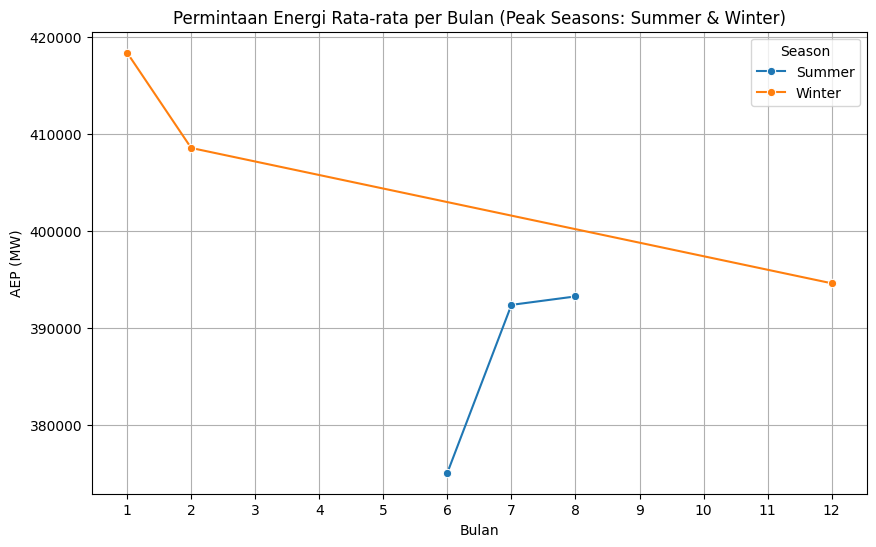

In [102]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.lineplot(data=monthly_peak_avg, x='Month', y='AEP_MW', hue='Season', marker='o')
plt.title('Permintaan Energi Rata-rata per Bulan (Peak Seasons: Summer & Winter)')
plt.xlabel('Bulan')
plt.ylabel('AEP (MW)')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


In [124]:
import pandas as pd

# Pastikan 'Date' sebagai datetime index jika belum
peak_seasons.index = pd.to_datetime(peak_seasons.index)

# Tambahkan kolom tahun
peak_seasons['Year'] = peak_seasons.index.year

# Hitung mean AEP per Season per Year
seasonal_mean = peak_seasons.groupby(['Year','Season'])['AEP_MW'].mean().reset_index()

# Tampilkan
print(seasonal_mean)


   Year  Season       AEP_MW
0  2016  Summer  5063.255431
1  2016  Winter  4932.383316
2  2017  Summer  4949.162582
3  2017  Winter  5032.841944
4  2018  Summer  5109.651495
5  2018  Winter  5034.166360


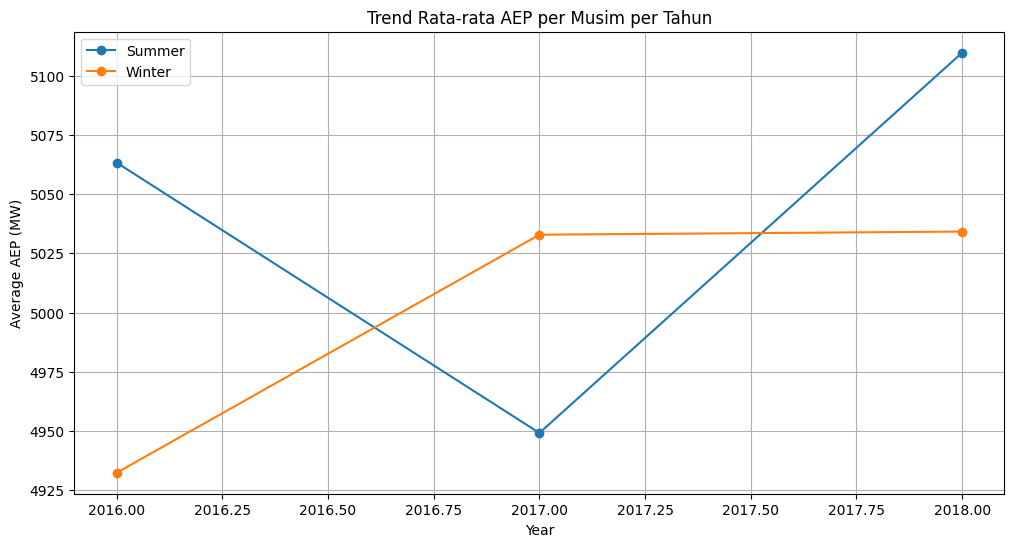

In [125]:
plt.figure(figsize=(12,6))
for season in ['Summer','Winter']:
    subset = seasonal_mean[seasonal_mean['Season']==season]
    plt.plot(subset['Year'], subset['AEP_MW'], marker='o', label=season)

plt.title('Trend Rata-rata AEP per Musim per Tahun')
plt.xlabel('Year')
plt.ylabel('Average AEP (MW)')
plt.legend()
plt.grid(True)
plt.show()


10:30:15 - cmdstanpy - INFO - Chain [1] start processing
10:30:17 - cmdstanpy - INFO - Chain [1] done processing
d:\Technical Class\Python\myvenv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(
10:30:17 - cmdstanpy - INFO - Chain [1] start processing
10:30:19 - cmdstanpy - INFO - Chain [1] done processing
d:\Technical Class\Python\myvenv\Lib\site-packages\prophet\forecaster.py:1872: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  dates = pd.date_range(


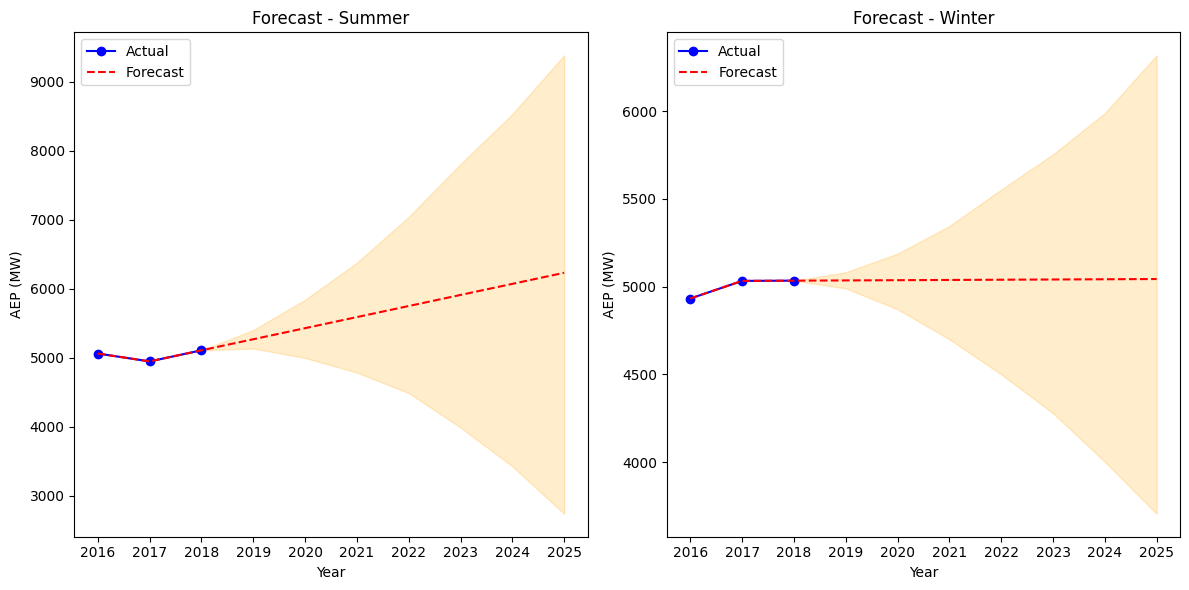

In [129]:
# --- 1. Import Library ---
import pandas as pd
from prophet import Prophet
import matplotlib.pyplot as plt

# --- 2. Data Contoh (ganti dengan datasetmu) ---
data = {
    "Year": [2016, 2016, 2017, 2017, 2018, 2018],
    "Season": ["Summer", "Winter", "Summer", "Winter", "Summer", "Winter"],
    "AEP_MW": [5063.25, 4932.38, 4949.16, 5032.84, 5109.65, 5034.16]
}
df = pd.DataFrame(data)

# --- 3. Siapkan Data untuk Prophet ---
# Prophet butuh kolom "ds" (datetime) dan "y" (target)
df["ds"] = pd.to_datetime(df["Year"].astype(str))
df = df.rename(columns={"AEP_MW": "y"})

# --- 4. Forecast per Season ---
seasons = df["Season"].unique()

plt.figure(figsize=(12, 6))

for i, season in enumerate(seasons, 1):
    # Filter season
    df_season = df[df["Season"] == season][["ds", "y"]]

    # Model Prophet
    model = Prophet(yearly_seasonality=False, weekly_seasonality=False, daily_seasonality=False)
    model.fit(df_season)

    # Buat future dataframe (sampai 2025)
    future = model.make_future_dataframe(periods=7, freq="Y")
    forecast = model.predict(future)

    # Plot hasil forecast
    plt.subplot(1, 2, i)
    plt.plot(df_season["ds"], df_season["y"], "bo-", label="Actual")
    plt.plot(forecast["ds"], forecast["yhat"], "r--", label="Forecast")
    plt.fill_between(forecast["ds"], forecast["yhat_lower"], forecast["yhat_upper"], alpha=0.2, color="orange")
    plt.title(f"Forecast - {season}")
    plt.xlabel("Year")
    plt.ylabel("AEP (MW)")
    plt.legend()

plt.tight_layout()
plt.show()


In [126]:
# Forecast sudah tersedia di 'forecast' DataFrame dari Prophet
# forecast['ds'] = tanggal, forecast['yhat'] = prediksi AEP

# Tambahkan kolom Year dan Season
forecast['Year'] = forecast['ds'].dt.year
forecast['Month'] = forecast['ds'].dt.month

def get_season(month):
    if month in [12,1,2]:
        return 'Winter'
    elif month in [6,7,8]:
        return 'Summer'
    else:
        return 'Other'

forecast['Season'] = forecast['Month'].apply(get_season)

# Hitung rata-rata forecast per musim per tahun
forecast_seasonal_mean = forecast.groupby(['Year','Season'])['yhat'].mean().reset_index()


In [127]:
# Tambahkan kolom 'Type' untuk membedakan
seasonal_mean['Type'] = 'Historical'
forecast_seasonal_mean.rename(columns={'yhat':'AEP_MW'}, inplace=True)
forecast_seasonal_mean['Type'] = 'Forecast'

combined = pd.concat([seasonal_mean, forecast_seasonal_mean], ignore_index=True)


C:\Users\72531\AppData\Local\Temp\ipykernel_28588\3352204373.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  peak_seasons['Rolling_Mean'] = peak_seasons['AEP_MW'].rolling(window=30).mean()


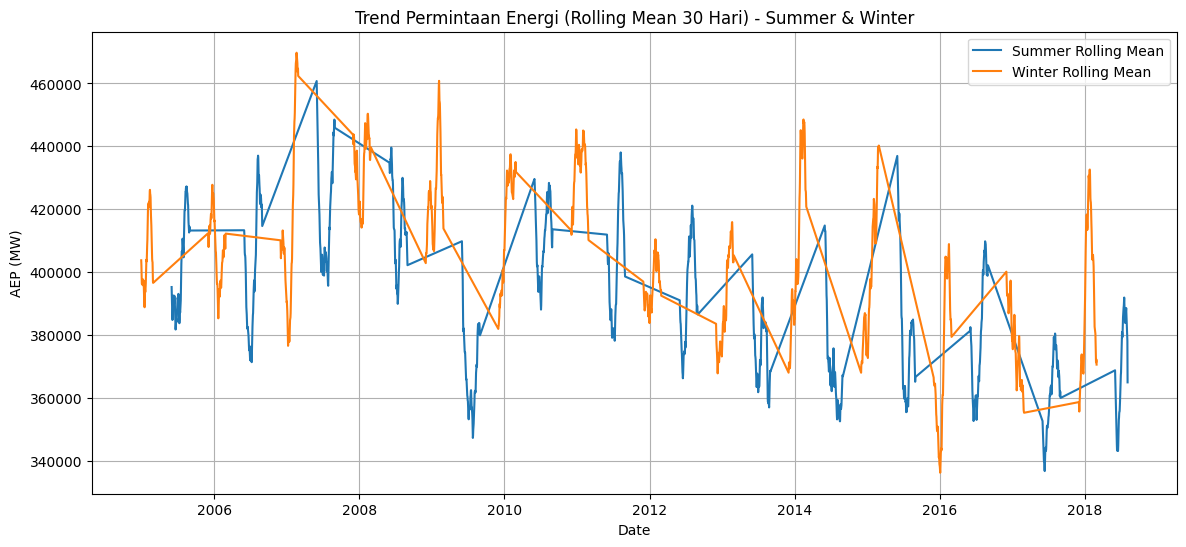

In [104]:
import matplotlib.pyplot as plt

# Rolling mean 30 hari
peak_seasons['Rolling_Mean'] = peak_seasons['AEP_MW'].rolling(window=30).mean()

# Plot
plt.figure(figsize=(14,6))
for season in ['Summer','Winter']:
    subset = peak_seasons[peak_seasons['Season']==season]
    plt.plot(subset.index, subset['Rolling_Mean'], label=f'{season} Rolling Mean')

plt.title('Trend Permintaan Energi (Rolling Mean 30 Hari) - Summer & Winter')
plt.xlabel('Date')
plt.ylabel('AEP (MW)')
plt.legend()
plt.grid(True)
plt.show()


In [97]:
# Filter hanya Summer & Winter
peak_seasons = daily_data[daily_data['Season'].isin(['Summer','Winter'])]


In [98]:
# Urutkan dari yang tertinggi
top_peak_days = peak_seasons.sort_values('AEP_MW', ascending=False).head(10)
print(top_peak_days[['AEP_MW','Season']])


              AEP_MW  Season
Datetime                    
2009-01-16  548349.0  Winter
2007-02-06  542682.0  Winter
2014-01-07  535660.0  Winter
2015-02-19  533988.0  Winter
2015-02-20  529129.0  Winter
2014-01-24  528058.0  Winter
2007-02-05  526420.0  Winter
2014-01-28  525861.0  Winter
2015-01-08  524960.0  Winter
2014-01-29  524931.0  Winter


In [94]:
# Reset index dan rename kolom
df_prophet = daily_data.reset_index().rename(columns={'Datetime':'ds', 'AEP_MW':'y'})

# Pastikan ds bertipe datetime
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

# Drop row yang ada NaN
df_prophet = df_prophet.dropna(subset=['ds','y'])

# Cek 5 baris pertama
print(df_prophet.head())
print(df_prophet.dtypes)


          ds         y  Month Season  Year
0 2004-10-01  328544.0     10   Fall  2004
1 2004-10-02  311997.0     10   Fall  2004
2 2004-10-03  293450.0     10   Fall  2004
3 2004-10-04  343417.0     10   Fall  2004
4 2004-10-05  346553.0     10   Fall  2004
ds        datetime64[ns]
y                float64
Month              int32
Season            object
Year               int32
dtype: object


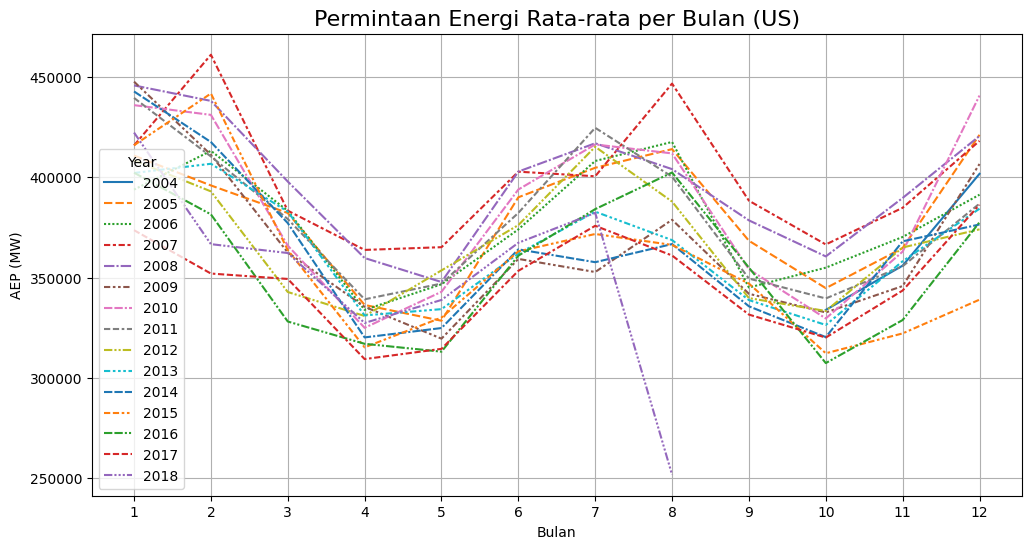

In [87]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Pastikan daily_data sudah ada dengan kolom 'AEP_MW' dan index datetime
daily_data['Month'] = daily_data.index.month
daily_data['Year'] = daily_data.index.year

# Rata-rata permintaan per bulan per tahun
monthly_avg = daily_data.groupby(['Year','Month'])['AEP_MW'].mean().reset_index()

# Pivot supaya bulan jadi kolom untuk visualisasi
pivot_df = monthly_avg.pivot(index='Month', columns='Year', values='AEP_MW')

# Visualisasi
plt.figure(figsize=(12,6))
sns.lineplot(data=pivot_df, palette='tab10')
plt.title('Permintaan Energi Rata-rata per Bulan (US)', fontsize=16)
plt.xlabel('Bulan')
plt.ylabel('AEP (MW)')
plt.xticks(range(1,13))
plt.grid(True)
plt.show()


01:24:30 - cmdstanpy - INFO - Chain [1] start processing
01:24:30 - cmdstanpy - INFO - Chain [1] done processing


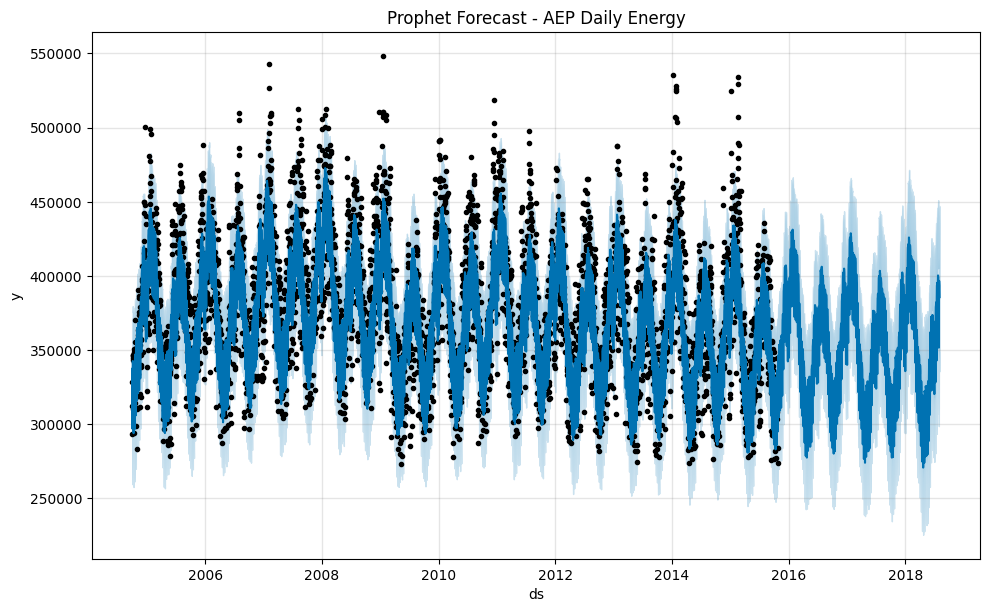

In [49]:
from prophet import Prophet

df = daily_data.reset_index().rename(columns={"Datetime": "ds", "AEP_MW": "y"})

train, test = df.iloc[:train_size], df.iloc[train_size:]

model = Prophet(daily_seasonality=False, yearly_seasonality=True)
model.fit(train)

future = model.make_future_dataframe(periods=len(test))
forecast = model.predict(future)

model.plot(forecast)
plt.title("Prophet Forecast - AEP Daily Energy")
plt.show()
